In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, trim
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import shutil
import os


# ============================================
# Step 1: Initialize Spark Session
# ============================================
spark = SparkSession.builder \
    .appName("KSRTC_Model_Training") \
    .getOrCreate()

print("✅ Spark session started successfully.")


# ============================================
# Step 2: Load Cleaned Data
# ============================================
data_path = ("D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\KSRTC_Project_Submission\\1.Jupyter Notebooks\\cleaned_ksrtc_data.parquet")

print(f"📂 Loading parquet file...")

try:
    data = spark.read.parquet(data_path)
    print(f"✅ Loaded {data.count()} records")
except Exception as e:
    print(f"❌ ERROR: {e}")
    spark.stop()
    exit()


# ============================================
# Step 3: Parse CSV String into Columns
# ============================================
print("\n🔧 Parsing CSV string into columns...")

col_name = data.columns[0]

data = data.withColumn("split_data", split(col(col_name), ","))

data = data.withColumn("ID", trim(data.split_data[0])) \
           .withColumn("Name", trim(data.split_data[1])) \
           .withColumn("Location", trim(data.split_data[2])) \
           .withColumn("Date", trim(data.split_data[3])) \
           .withColumn("Arrival_Time", trim(data.split_data[4])) \
           .withColumn("Departure_Time", trim(data.split_data[5])) \
           .withColumn("Fare", trim(data.split_data[6])) \
           .withColumn("Price", trim(data.split_data[7]))

data = data.drop(col_name, "split_data")

print("✓ Columns parsed successfully")
print(f"📋 Columns: {data.columns}")


# ============================================
# Step 4: Define Features and Target
# ============================================
target_col = "Fare"
print(f"\n🎯 Target: {target_col}")

categorical_cols = ["Name", "Location"]
numerical_cols = ["ID"]

# Check unique values in categorical columns
print("\n📊 Checking categorical feature cardinality...")
for c in categorical_cols:
    unique_count = data.select(c).distinct().count()
    print(f"   {c}: {unique_count} unique values")


# ============================================
# Step 5: Clean Data
# ============================================
print("\n🧹 Cleaning data...")

data_clean = data
for c in [target_col] + categorical_cols + numerical_cols:
    data_clean = data_clean.filter(col(c).isNotNull())

print(f"✓ Records after cleaning: {data_clean.count()}")

data_clean = data_clean.withColumn(target_col, col(target_col).cast("double"))
for c in numerical_cols:
    data_clean = data_clean.withColumn(c, col(c).cast("double"))

print("✓ Data types converted")


# ============================================
# Step 6: Build ML Pipeline
# ============================================
print("\n⚙️ Building ML Pipeline...")

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_Idx", handleInvalid="skip")
    for c in categorical_cols
]

feature_cols = [f"{c}_Idx" for c in categorical_cols] + numerical_cols
print(f"📊 Feature columns: {feature_cols}")

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

# CRITICAL FIX: Increase maxBins to handle categorical features with many unique values
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_col,
    numTrees=50,
    maxDepth=10,
    maxBins=256,  # Increased from default 32 to handle 148 unique values in "Name"
    seed=42
)

pipeline = Pipeline(stages=indexers + [assembler, rf])
print("✓ Pipeline created with maxBins=256")


# ============================================
# Step 7: Train Model
# ============================================
train_df, test_df = data_clean.randomSplit([0.8, 0.2], seed=42)
print(f"\n📊 Training: {train_df.count()}, Testing: {test_df.count()}")

print("🔄 Training model...")
trained_model = pipeline.fit(train_df)
print("✅ Model training complete!")


# ============================================
# Step 8: Evaluate Model
# ============================================
print("\n📈 Evaluating model...")
predictions = trained_model.transform(test_df)

print("\n--- Sample Predictions ---")
predictions.select(target_col, "prediction").show(10, truncate=False)

evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print(f"\n📊 Performance Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   R² Score: {r2:.4f}")
print(f"   MAE: {mae:.4f}")


# ============================================
# Step 9: Save Model
# ============================================
model_dir = "ksrtc_fare_prediction_model"
if os.path.exists(model_dir):
    shutil.rmtree(model_dir)

trained_model.write().overwrite().save(model_dir)
print(f"\n💾 Model saved to: {os.path.abspath(model_dir)}")


# ============================================
# Step 10: Feature Importance
# ============================================
print("\n🔍 Feature Importance:")
rf_model = trained_model.stages[-1]
importances = rf_model.featureImportances.toArray()

for idx, importance in enumerate(importances):
    if idx < len(feature_cols):
        print(f"   {feature_cols[idx]}: {importance:.4f}")


# ============================================
# Step 11: Stop Spark
# ============================================
spark.stop()
print("\n✅ Model Training Complete!")


✅ Spark session started successfully.
📂 Loading parquet file...
✅ Loaded 1000 records

🔧 Parsing CSV string into columns...
✓ Columns parsed successfully
📋 Columns: ['ID', 'Name', 'Location', 'Date', 'Arrival_Time', 'Departure_Time', 'Fare', 'Price']

🎯 Target: Fare

📊 Checking categorical feature cardinality...
   Name: 154 unique values
   Location: 6 unique values

🧹 Cleaning data...
✓ Records after cleaning: 1000
✓ Data types converted

⚙️ Building ML Pipeline...
📊 Feature columns: ['Name_Idx', 'Location_Idx', 'ID']
✓ Pipeline created with maxBins=256

📊 Training: 838, Testing: 162
🔄 Training model...
✅ Model training complete!

📈 Evaluating model...

--- Sample Predictions ---
+------+------------------+
|Fare  |prediction        |
+------+------------------+
|180.25|183.49214277693673|
|220.3 |169.56338957258936|
|210.2 |233.19124546837438|
|135.5 |174.80460082856018|
|340.4 |263.93882771158775|
|280.7 |282.3250592358822 |
|150.1 |180.11062346525546|
|105.4 |139.9572964246663 |
|

✅ Spark session started successfully.
📂 Loading parquet file...
✅ Loaded 1000 records

🔧 Parsing CSV string into columns...
✓ Columns parsed successfully
📋 Columns: ['ID', 'Name', 'Location', 'Date', 'Arrival_Time', 'Departure_Time', 'Fare', 'Price']

🎯 Target: Fare

📊 Checking categorical feature cardinality...
   Name: 154 unique values
   Location: 6 unique values

🧹 Cleaning data...
✓ Records after cleaning: 1000
✓ Data types converted

⚙️ Building ML Pipeline...
📊 Feature columns: ['Name_Idx', 'Location_Idx', 'ID']
✓ Pipeline created with maxBins=256

📊 Training: 838, Testing: 162
🔄 Training model...
✅ Model training complete!

📈 Evaluating model...

--- Sample Predictions ---
+------+------------------+
|Fare  |prediction        |
+------+------------------+
|180.25|183.49214277693673|
|220.3 |169.56338957258936|
|210.2 |233.19124546837438|
|135.5 |174.80460082856018|
|340.4 |263.93882771158775|
|280.7 |282.3250592358822 |
|150.1 |180.11062346525546|
|105.4 |139.9572964246663 |
|

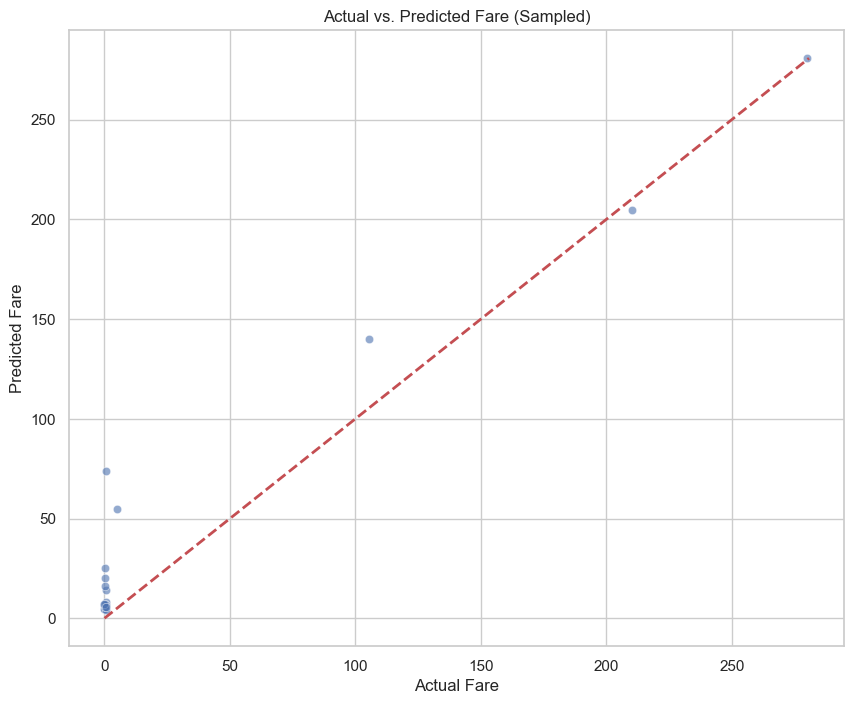

   - Plotting Feature Importance...


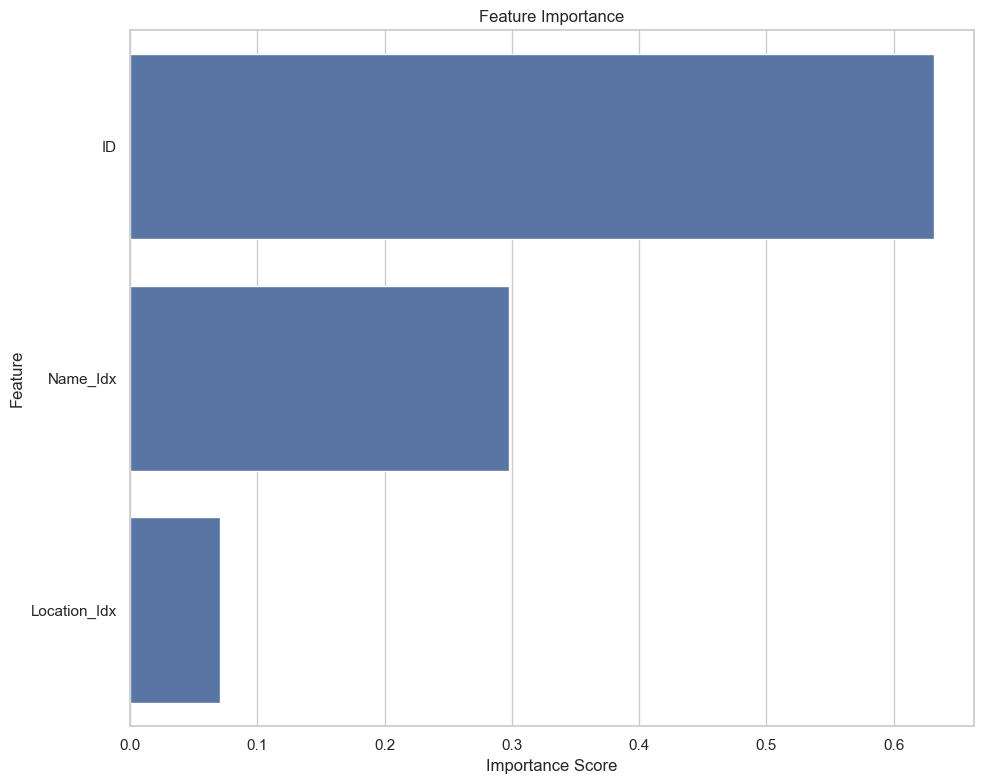


💾 Model saved to: d:\Rachith Bharadwaj T N 24BDS062\2nd Year\3rd SEM\AI Project\KSRTC_Project_Submission\1.Jupyter Notebooks\ksrtc_fare_prediction_model

🔍 Feature Importance:
   Name_Idx: 0.2977
   Location_Idx: 0.0708
   ID: 0.6315

✅ Model Training Complete!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, split, trim
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml import Pipeline
import shutil
import os


# ============================================
# Step 1: Initialize Spark Session
# ============================================
spark = SparkSession.builder \
    .appName("KSRTC_Model_Training") \
    .getOrCreate()

print("✅ Spark session started successfully.")


# ============================================
# Step 2: Load Cleaned Data
# ============================================
data_path = ("D:\\Rachith Bharadwaj T N 24BDS062\\2nd Year\\3rd SEM\\AI Project\\KSRTC_Project_Submission\\1.Jupyter Notebooks\\cleaned_ksrtc_data.parquet")

print(f"📂 Loading parquet file...")

try:
    data = spark.read.parquet(data_path)
    print(f"✅ Loaded {data.count()} records")
except Exception as e:
    print(f"❌ ERROR: {e}")
    spark.stop()
    exit()


# ============================================
# Step 3: Parse CSV String into Columns
# ============================================
print("\n🔧 Parsing CSV string into columns...")

# This step is necessary because the parquet file is malformed
col_name = data.columns[0]

data = data.withColumn("split_data", split(col(col_name), ","))

data = data.withColumn("ID", trim(data.split_data[0])) \
           .withColumn("Name", trim(data.split_data[1])) \
           .withColumn("Location", trim(data.split_data[2])) \
           .withColumn("Date", trim(data.split_data[3])) \
           .withColumn("Arrival_Time", trim(data.split_data[4])) \
           .withColumn("Departure_Time", trim(data.split_data[5])) \
           .withColumn("Fare", trim(data.split_data[6])) \
           .withColumn("Price", trim(data.split_data[7]))

data = data.drop(col_name, "split_data")

print("✓ Columns parsed successfully")
print(f"📋 Columns: {data.columns}")


# ============================================
# Step 4: Define Features and Target
# ============================================
target_col = "Fare"
print(f"\n🎯 Target: {target_col}")

categorical_cols = ["Name", "Location"]
numerical_cols = ["ID"]

# Check unique values in categorical columns
print("\n📊 Checking categorical feature cardinality...")
for c in categorical_cols:
    unique_count = data.select(c).distinct().count()
    print(f"   {c}: {unique_count} unique values")


# ============================================
# Step 5: Clean Data
# ============================================
print("\n🧹 Cleaning data...")

data_clean = data
for c in [target_col] + categorical_cols + numerical_cols:
    data_clean = data_clean.filter(col(c).isNotNull())

print(f"✓ Records after cleaning: {data_clean.count()}")

data_clean = data_clean.withColumn(target_col, col(target_col).cast("double"))
for c in numerical_cols:
    data_clean = data_clean.withColumn(c, col(c).cast("double"))

print("✓ Data types converted")


# ============================================
# Step 6: Build ML Pipeline
# ============================================
print("\n⚙️ Building ML Pipeline...")

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_Idx", handleInvalid="skip")
    for c in categorical_cols
]

feature_cols = [f"{c}_Idx" for c in categorical_cols] + numerical_cols
print(f"📊 Feature columns: {feature_cols}")

assembler = VectorAssembler(
    inputCols=feature_cols,
    outputCol="features",
    handleInvalid="skip"
)

# CRITICAL FIX: Increase maxBins to handle categorical features with many unique values
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol=target_col,
    numTrees=50,
    maxDepth=10,
    maxBins=256,  # Increased from default 32 to handle 148 unique values in "Name"
    seed=42
)

pipeline = Pipeline(stages=indexers + [assembler, rf])
print("✓ Pipeline created with maxBins=256")


# ============================================
# Step 7: Train Model
# ============================================
train_df, test_df = data_clean.randomSplit([0.8, 0.2], seed=42)
print(f"\n📊 Training: {train_df.count()}, Testing: {test_df.count()}")

print("🔄 Training model...")
trained_model = pipeline.fit(train_df)
print("✅ Model training complete!")


# ============================================
# Step 8: Evaluate Model
# ============================================
print("\n📈 Evaluating model...")
predictions = trained_model.transform(test_df)

print("\n--- Sample Predictions ---")
predictions.select(target_col, "prediction").show(10, truncate=False)

evaluator_rmse = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="rmse")
evaluator_r2 = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="r2")
evaluator_mae = RegressionEvaluator(labelCol=target_col, predictionCol="prediction", metricName="mae")

rmse = evaluator_rmse.evaluate(predictions)
r2 = evaluator_r2.evaluate(predictions)
mae = evaluator_mae.evaluate(predictions)

print(f"\n📊 Performance Metrics:")
print(f"   RMSE: {rmse:.4f}")
print(f"   R² Score: {r2:.4f}")
print(f"   MAE: {mae:.4f}")


# ============================================
# Step 9: 📊 Visualize Model Results (NEW)
# ============================================
print("\n📊 Generating visualizations...")
sns.set_theme(style="whitegrid")

# --- Plot 1: Actual vs. Predicted Scatter Plot ---
try:
    print("   - Plotting Actual vs. Predicted...")
    # Sample the predictions to avoid crashing pandas
    pred_sample_pd = predictions.select(target_col, "prediction") \
                                .sample(withReplacement=False, fraction=0.1, seed=42) \
                                .limit(1000) \
                                .toPandas()

    plt.figure(figsize=(10, 8))
    sns.scatterplot(data=pred_sample_pd, x=target_col, y="prediction", alpha=0.6)
    
    # Add a 45-degree line (perfect prediction)
    min_val = min(pred_sample_pd[target_col].min(), pred_sample_pd["prediction"].min())
    max_val = max(pred_sample_pd[target_col].max(), pred_sample_pd["prediction"].max())
    plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)
    
    plt.title("Actual vs. Predicted Fare (Sampled)")
    plt.xlabel("Actual Fare")
    plt.ylabel("Predicted Fare")
    plt.show()

except Exception as e:
    print(f"   ⚠️ Could not plot Actual vs. Predicted: {e}")

# --- Plot 2: Feature Importance Bar Plot ---
try:
    print("   - Plotting Feature Importance...")
    rf_model = trained_model.stages[-1]
    importances = rf_model.featureImportances.toArray()
    
    # Create a pandas DataFrame
    imp_df = pd.DataFrame({
        'feature': feature_cols,
        'importance': importances
    }).sort_values(by='importance', ascending=False)
    
    plt.figure(figsize=(10, 8))
    sns.barplot(data=imp_df, x='importance', y='feature', orient='h')
    plt.title("Feature Importance")
    plt.xlabel("Importance Score")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"   ⚠️ Could not plot Feature Importance: {e}")


# ============================================
# Step 10: Save Model
# ============================================
model_dir = "ksrtc_fare_prediction_model"
if os.path.exists(model_dir):
    shutil.rmtree(model_dir)

trained_model.write().overwrite().save(model_dir)
print(f"\n💾 Model saved to: {os.path.abspath(model_dir)}")


# ============================================
# Step 11: Feature Importance (from your code)
# ============================================
print("\n🔍 Feature Importance:")
rf_model = trained_model.stages[-1]
importances = rf_model.featureImportances.toArray()

for idx, importance in enumerate(importances):
    if idx < len(feature_cols):
        print(f"   {feature_cols[idx]}: {importance:.4f}")


# ============================================
# Step 12: Stop Spark
# ============================================
spark.stop()
print("\n✅ Model Training Complete!")